# 02 – EDA and Preprocessing
Clean the JD and resume text, remove duplicates, and create a validation split.

## Load data
Load the JD/resume splits saved by notebook 01.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd, re
data_dir = "/content/drive/MyDrive/resume-jd-matching/data"
train = pd.read_parquet(f"{data_dir}/train_split.parquet")
test = pd.read_parquet(f"{data_dir}/test_split.parquet")
print(train.shape, test.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(6241, 3) (1759, 3)


## Measure noise
Count rows with emails, URLs, phones, stuck words, special characters and extra spaces.

In [2]:
checks = {
    "email": r"[\w.+-]+@[\w-]+\.[\w.]+",
    "url": r"https?://\S+|www\.\S+",
    "phone": r"\(?\d{3}\)?[\s.-]?\d{3}[\s.-]?\d{4}",
    "stuck_words": r"[a-z][A-Z][a-z]",
    "non_ascii": r"[^\x00-\x7F]",
    "multi_space": r"\s{3,}",
}

rows = []
for col in ["jd", "resume"]:
    for name, pat in checks.items():
        hits = train[col].str.contains(pat, regex=True)
        rows.append({"column": col, "check": name, "rows_affected": hits.sum(),
                     "pct": round(hits.mean() * 100, 1)})
print(pd.DataFrame(rows).to_string(index=False))

column       check  rows_affected   pct
    jd       email            985  15.8
    jd         url            468   7.5
    jd       phone            317   5.1
    jd stuck_words           5375  86.1
    jd   non_ascii             20   0.3
    jd multi_space            750  12.0
resume       email             32   0.5
resume         url            227   3.6
resume       phone             44   0.7
resume stuck_words           6241 100.0
resume   non_ascii           5330  85.4
resume multi_space           1525  24.4


## Noise examples
Look at real examples of each issue before writing cleaning rules.

In [3]:
for col in ["jd", "resume"]:
    for name in ["email", "phone", "stuck_words", "non_ascii"]:
        found = train[col].str.findall(checks[name]).explode().dropna()
        print(f"--- {col} | {name} | sample ---")
        print(found.head(8).tolist())

--- jd | email | sample ---
['Inc.prashant.singh@net2source.comDirect', 'careers@selinc.com.', 'info@mizickmiller.com', 'saran@focuzmindz.com', 'christina.meng@storm2.com', 'RecruiterNisha.j@peritussoft.com', 'RecruiterNisha.j@peritussoft.com', 'saran@focuzmindz.com']
--- jd | phone | sample ---
['(201) 285-5087', '(201) 340-8700', '(201) 221-8131', '469-824-3140', '469-824-3140', '228.474.6383', '469-947-7816', '844-694-4748']
--- jd | stuck_words | sample ---
['tLo', 'dHi', 'hSr', 'sNe', 'mDi', 'dIn', 'hSe', 'kYo']
--- jd | non_ascii | sample ---
['\xa0', '\xa0', '\xa0', '\xa0', '\xa0', '\xa0', '\xa0', '\xa0']
--- resume | email | sample ---
['432-1000resumesample@example.comStaffing', 'resumesample@example.com', 'resumesample@example.com', 'users.resumesample@example.com', '432-1000resumesample@example.comStaffing', 'users.resumesample@example.com', 'users.resumesample@example.com', 'users.resumesample@example.com']
--- resume | phone | sample ---
['(555) 432-1000', '800 367 2884', 

## Duplicates
Check duplicate JD+resume pairs, conflicting labels, and unique JDs and resumes.

In [4]:
print("Duplicate JD+resume pairs in train:", train.duplicated(subset=["jd", "resume"]).sum())
print("Same pair with different labels:",
      train.groupby(["jd", "resume"])["label"].nunique().gt(1).sum())
print("Unique JDs in train:", train["jd"].nunique(), "of", len(train))
print("Unique resumes in train:", train["resume"].nunique(), "of", len(train))

Duplicate JD+resume pairs in train: 7
Same pair with different labels: 6
Unique JDs in train: 280 of 6241
Unique resumes in train: 642 of 6241


## Checks before cleaning
Find genuine camelCase terms to protect, JD/resume overlap between train and test, signatures, and conflicting pairs.

In [5]:
# 1. Genuine camelCase terms that splitting would break
camel = pd.concat([train["jd"], train["resume"]]).str.findall(r"\b[A-Za-z]*[a-z][A-Z][A-Za-z]*\b").explode().dropna()
print(camel.value_counts().head(60).to_string())

# 2. JD / resume overlap between train and test
print("\nTest rows whose JD is in train:", round(test["jd"].isin(train["jd"]).mean(), 3))
print("Test rows whose resume is in train:", round(test["resume"].isin(train["resume"]).mean(), 3))
print("Unique JDs in test:", test["jd"].nunique(), "| Unique resumes in test:", test["resume"].nunique())

# 3. Recruiter signatures
print("\nJDs containing 'Regards':", train["jd"].str.contains(r"\bRegards\b", case=False).sum())

# 4. The conflicting pairs
conf = train.groupby(["jd", "resume"])["label"].agg(lambda s: sorted(s.unique()))
print("\nConflicting label sets:", conf[conf.str.len() > 1].tolist())

JavaScript                 4031
MySQL                      2346
PowerPoint                 1601
EducationExpected          1561
SharePoint                 1309
PostgreSQL                 1299
inMay                      1237
jQuery                     1157
DevOps                     1078
iOS                        1032
QuickBooks                 1013
MongoDB                    1000
TrainingExpected            820
NoSQL                       813
MapReduce                   638
SummaryHighly               595
ExperienceSoftware          550
AutoCAD                     523
IoT                         515
WebDriver                   478
PySpark                     424
EducationMaster             424
TestNG                      414
expertiseLoss               400
operationsProduct           400
proceduresMerchandising     400
servicesInventory           400
preventionCash              400
AngularJS                   362
GitHub                      353
SummaryTo                   331
SaaS    

## Cleaning function
Normalise characters, remove emails/URLs/phones, split stuck words (keeping protected terms), collapse spaces.

In [6]:
PROTECTED = ["JavaScript", "MySQL", "PowerPoint", "SharePoint", "PostgreSQL", "jQuery", "DevOps", "iOS",
             "QuickBooks", "MongoDB", "NoSQL", "MapReduce", "AutoCAD", "IoT", "WebDriver", "PySpark",
             "TestNG", "AngularJS", "GitHub", "SaaS", "DynamoDB", "TypeScript", "BigQuery", "MatLab",
             "ProvideX", "PeopleSoft", "CloudWatch", "IntelliJ", "WinForms", "CloudFormation"]

def camel_split(s):
    return re.sub(r"([a-z])([A-Z])", r"\1 \2", s)

# After splitting, join protected terms back together (e.g. "Java Script" -> "JavaScript")
RESTORE = [(re.compile(r"\b" + re.escape(camel_split(t)) + r"\b"), t) for t in PROTECTED]

def clean_text(s):
    s = s.replace("\xa0", " ").replace("–", "-").replace("—", "-")       # rule 1
    s = re.sub(r"\[[^\]]*\]\(mailto:[^)]*\)", " ", s)                    # rule 2: markdown mailto links
    s = re.sub(r"[\w.+-]+@[\w-]+\.[\w.]+", " ", s)                       # rule 2: emails
    s = re.sub(r"https?://\S+|www\.\S+", " ", s)                         # rule 2: URLs
    s = re.sub(r"\(?\d{3}\)?[\s.-]?\d{3}[\s.-]?\d{4}", " ", s)           # rule 2: phones
    s = camel_split(s)                                                   # rule 3: split stuck words
    for pat, term in RESTORE:                                            # rule 3: keep protected terms
        s = pat.sub(term, s)
    return re.sub(r"\s+", " ", s).strip()                                # rule 4 (case kept: rule 5)

print(clean_text("SummaryHighly skilled in JavaScript and MySQL. Contact [a@b.com](mailto:a@b.com) (201) 285-5087"))

Summary Highly skilled in JavaScript and MySQL. Contact


## Apply cleaning
Clean all rows and re-measure the noise.

In [7]:
for df in (train, test):
    df["jd"] = df["jd"].map(clean_text)
    df["resume"] = df["resume"].map(clean_text)

rows = []
for col in ["jd", "resume"]:
    for name in ["email", "url", "phone", "stuck_words", "non_ascii", "multi_space"]:
        rows.append({"column": col, "check": name,
                     "pct_after": round(train[col].str.contains(checks[name], regex=True).mean() * 100, 1)})
print(pd.DataFrame(rows).to_string(index=False))
print("\nResume sample:\n", train.loc[0, "resume"][:400])

column       check  pct_after
    jd       email        0.0
    jd         url        0.0
    jd       phone        0.1
    jd stuck_words       27.6
    jd   non_ascii        0.0
    jd multi_space        0.0
resume       email        0.0
resume         url        0.0
resume       phone        0.0
resume stuck_words       58.0
resume   non_ascii       28.2
resume multi_space        0.0

Resume sample:
 Summary Highly motivated Sales Associate with extensive customer service and sales experience. Outgoing sales professional with track record of driving increased sales, improving buying experience and elevating company profile with target market. Highlights-Soft Skills: Public Speaking, Public Relations, Team Building, Project Management, Procedure writing, Staff Supervision and Management, Abilit


## Remove label noise
Drop the 6 conflicting pairs (12 rows) and 1 exact duplicate. Test is not deduplicated.

In [8]:
before = len(train)
conflict = train.groupby(["jd", "resume"])["label"].transform("nunique") > 1
print("Rows in conflicting pairs:", conflict.sum())
train = train[~conflict]

dups = train.duplicated(subset=["jd", "resume", "label"])
print("Exact duplicate rows:", dups.sum())
train = train[~dups].reset_index(drop=True)
print("Train rows:", before, "->", len(train))

print("Test duplicate pairs (kept, test is not modified):", test.duplicated(subset=["jd", "resume"]).sum())

Rows in conflicting pairs: 12
Exact duplicate rows: 1
Train rows: 6241 -> 6228
Test duplicate pairs (kept, test is not modified): 0


## Validation split
Hold out about 15% of JDs (all their rows) with StratifiedGroupKFold, because test JDs never appear in train.

In [9]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=42)
groups = train["jd"].factorize()[0]
tr_idx, val_idx = next(sgkf.split(train, train["label"], groups))

train_final = train.iloc[tr_idx].reset_index(drop=True)
val = train.iloc[val_idx].reset_index(drop=True)

print("Rows  -> train:", len(train_final), "| val:", len(val), "| test:", len(test))
print("JDs   -> train:", train_final["jd"].nunique(), "| val:", val["jd"].nunique(), "| test:", test["jd"].nunique())
print("JD overlap train/val:", val["jd"].isin(train_final["jd"]).sum())
print(pd.concat([train_final["label"].value_counts(normalize=True),
                 val["label"].value_counts(normalize=True),
                 test["label"].value_counts(normalize=True)],
                axis=1, keys=["train", "val", "test"]).round(3))

Rows  -> train: 5285 | val: 943 | test: 1759
JDs   -> train: 240 | val: 40 | test: 71
JD overlap train/val: 0
               train    val   test
label                             
No Fit         0.507  0.486  0.487
Potential Fit  0.250  0.247  0.252
Good Fit       0.243  0.267  0.260


## Save
Save clean train, validation and test sets to Google Drive.

In [10]:
train_final.to_parquet(f"{data_dir}/train_clean.parquet", index=False)
val.to_parquet(f"{data_dir}/val_clean.parquet", index=False)
test.to_parquet(f"{data_dir}/test_clean.parquet", index=False)
print("Saved:", train_final.shape, val.shape, test.shape)

Saved: (5285, 3) (943, 3) (1759, 3)


## Verify cleaning
Confirm only protected camelCase terms and harmless characters remain.

In [11]:
from collections import Counter

camel_left = pd.concat([train_final["jd"], train_final["resume"]]).str.findall(
    r"\b[A-Za-z]*[a-z][A-Z][A-Za-z]*\b").explode().dropna()
others = camel_left[~camel_left.isin(PROTECTED)]
print("CamelCase tokens left:", len(camel_left), "| not in protected list:", len(others))
print(others.value_counts().head(25).to_string())

chars = Counter(c for t in train_final["resume"] for c in t if ord(c) > 127)
print("\nTop non-ASCII characters:", [(c, hex(ord(c)), n) for c, n in chars.most_common(10)])

CamelCase tokens left: 22150 | not in protected list: 0
Series([], )

Top non-ASCII characters: [('•', '0x2022', 2008), ('·', '0xb7', 1559), ('’', '0x2019', 1505), ('➢', '0x27a2', 774), ('\u200b', '0x200b', 557), ('∂', '0x2202', 539), ('❖', '0x2756', 297), ('\uf0d8', '0xf0d8', 288), ('“', '0x201c', 215), ('”', '0x201d', 203)]


## EDA charts
Visual checks on the cleaned data. Charts are saved to Drive for the slides.

### Setup

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_parquet(f"{data_dir}/train_clean.parquet")
val = pd.read_parquet(f"{data_dir}/val_clean.parquet")
test = pd.read_parquet(f"{data_dir}/test_clean.parquet")

fig_dir = "/content/drive/MyDrive/resume-jd-matching/reports/figures"
os.makedirs(fig_dir, exist_ok=True)
order = ["No Fit", "Potential Fit", "Good Fit"]
print(train.shape, val.shape, test.shape)

(5285, 3) (943, 3) (1759, 3)


### Label distribution
Question: are the classes balanced, and are the splits similar?

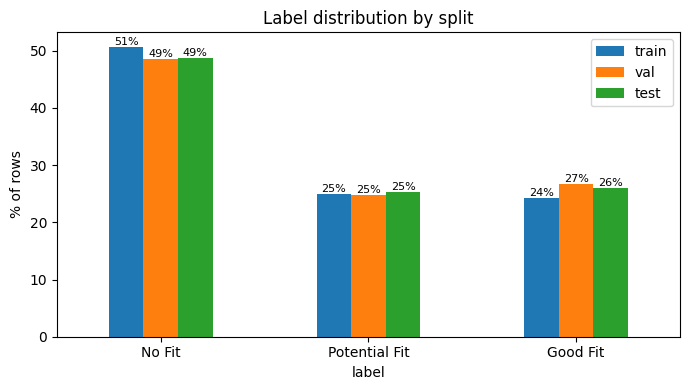

In [13]:
counts = pd.concat({n: d["label"].value_counts(normalize=True)
                    for n, d in [("train", train), ("val", val), ("test", test)]}, axis=1).loc[order] * 100
ax = counts.plot(kind="bar", figsize=(7, 4), rot=0)
ax.set_ylabel("% of rows"); ax.set_title("Label distribution by split")
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f%%", fontsize=8)
plt.tight_layout(); plt.savefig(f"{fig_dir}/01_label_distribution.png", dpi=150); plt.show()

### Text length by label
Question: does length differ between labels, and how much text exceeds BERT's limit?

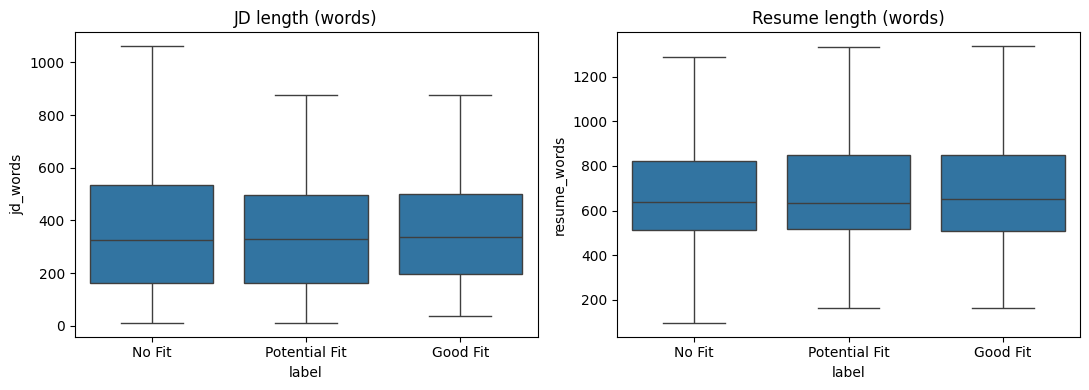

               jd_words  resume_words
label                                
No Fit            324.0         636.0
Potential Fit     331.0         633.0
Good Fit          339.0         653.0

Rows over ~400 words combined (roughly over BERT's 512 tokens): 98.4%


In [14]:
train["jd_words"] = train["jd"].str.split().str.len()
train["resume_words"] = train["resume"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=train, x="label", y="jd_words", order=order, ax=axes[0], showfliers=False)
sns.boxplot(data=train, x="label", y="resume_words", order=order, ax=axes[1], showfliers=False)
axes[0].set_title("JD length (words)"); axes[1].set_title("Resume length (words)")
plt.tight_layout(); plt.savefig(f"{fig_dir}/02_text_length.png", dpi=150); plt.show()

print(train.groupby("label")[["jd_words", "resume_words"]].median().loc[order])
total = train["jd_words"] + train["resume_words"]
print(f"\nRows over ~400 words combined (roughly over BERT's 512 tokens): {(total > 400).mean():.1%}")

### Resumes per JD
Question: can we evaluate ranking, meaning does each JD have enough resumes with mixed labels?

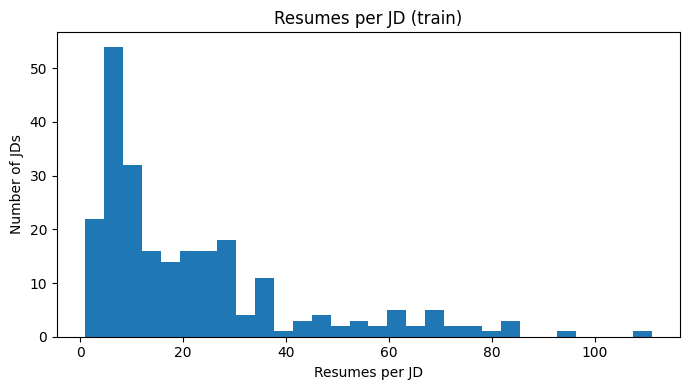

count    240.0
mean      22.0
std       20.8
min        1.0
25%        7.0
50%       14.0
75%       29.0
max      111.0
dtype: float64

JDs with all 3 labels: 24.2%
JDs with only 1 label: 13.8%


In [15]:
per_jd = train.groupby("jd").size()
plt.figure(figsize=(7, 4))
plt.hist(per_jd, bins=30)
plt.xlabel("Resumes per JD"); plt.ylabel("Number of JDs"); plt.title("Resumes per JD (train)")
plt.tight_layout(); plt.savefig(f"{fig_dir}/03_resumes_per_jd.png", dpi=150); plt.show()

print(per_jd.describe().round(1))
labels_per_jd = train.groupby("jd")["label"].nunique()
print("\nJDs with all 3 labels:", f"{(labels_per_jd == 3).mean():.1%}")
print("JDs with only 1 label:", f"{(labels_per_jd == 1).mean():.1%}")

### Word overlap by label
Question: is there a matching signal, meaning do Good Fit resumes share more words with the JD?

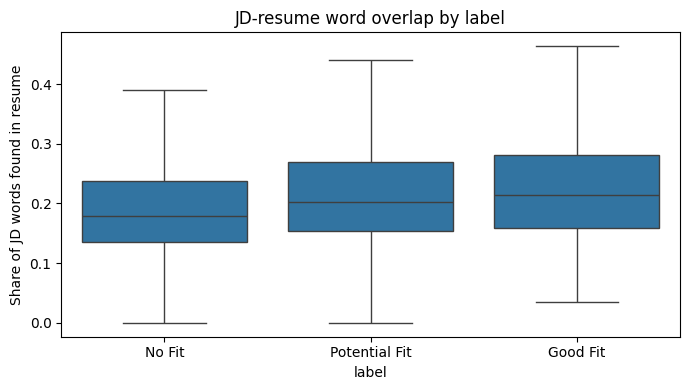

label
No Fit           0.178
Potential Fit    0.202
Good Fit         0.215
Name: overlap, dtype: float64


In [16]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS as STOP

def words(s):
    return {w for w in re.findall(r"[a-z][a-z+#]+", s.lower()) if w not in STOP}

train["overlap"] = [len(words(j) & words(r)) / max(len(words(j)), 1)
                    for j, r in zip(train["jd"], train["resume"])]

plt.figure(figsize=(7, 4))
sns.boxplot(data=train, x="label", y="overlap", order=order, showfliers=False)
plt.ylabel("Share of JD words found in resume"); plt.title("JD-resume word overlap by label")
plt.tight_layout(); plt.savefig(f"{fig_dir}/04_word_overlap.png", dpi=150); plt.show()

print(train.groupby("label")["overlap"].median().loc[order].round(3))

## EDA findings
- Labels: ~50% No Fit, ~25% Potential Fit, ~25% Good Fit, consistent across splits → use macro F1 and class weights.
- Text length is nearly identical across labels → length is not a useful signal.
- 98.4% of rows exceed ~512 BERT tokens → transformer model needs truncation.
- Resumes per JD: median 14 (range 1–111); only 24% of JDs have all 3 labels → ranking metrics use JDs with at least 2 labels.
- JD-resume word overlap rises with fit (0.178 → 0.202 → 0.215) but overlaps heavily → keyword matching alone is weak; embeddings and skill features are needed.

## Dataset limitations
- No dataset card: the source of the labels and how they were assigned is not documented.
- Train rows contained the label inside the text ("The result is, ..."); this was removed. Test rows did not.
- 6 JD+resume pairs had conflicting labels (12 rows); they were removed as label noise.
- Resumes appear anonymised (placeholder emails and 555 phone numbers) and are reused heavily:
  642 unique resumes across 6,241 train rows, and 99.9% of test resumes also appear in train.
- Test JDs never appear in train, so the task measures generalisation to new jobs.
- Texts are long (average about 8,600 characters), beyond BERT's 512-token limit.